<a href="https://colab.research.google.com/github/Avi0095/Deep-Learning-Project/blob/main/Stroke_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving archive.zip to archive.zip


In [ ]:
!unzip archive.zip

unzip:  cannot find or open archive.zip, archive.zip.zip or archive.zip.ZIP.


In [ ]:
!ls

archive.zip  Brain_Data_Organised  sample_data


import the library

In [ ]:
import torch
import torch.nn as nn
import torchvision
from torchvision import transforms, datasets, models
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import cv2

process the image

In [ ]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

load dataset

In [ ]:
dataset = datasets.ImageFolder(
    "Brain_Data_Organised",
    transform=transform
)

print("Classes:", dataset.classes)
print("Total Images:", len(dataset))

Classes: ['Normal', 'Stroke']
Total Images: 2501


train/test split

In [ ]:
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_dataset, test_dataset = random_split(dataset,[train_size,test_size])

train_loader = DataLoader(train_dataset,batch_size=16,shuffle=True)
test_loader = DataLoader(test_dataset,batch_size=16)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

CNN

In [ ]:
class CNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(3,16,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16,32,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc = nn.Sequential(
            nn.Linear(32*56*56,128),
            nn.ReLU(),
            nn.Linear(128,2)
        )

    def forward(self,x):
        x=self.conv(x)
        x=x.view(x.size(0),-1)
        return self.fc(x)

ResNet50

In [ ]:
def get_resnet():

    model = models.resnet50(pretrained=True)

    model.fc = nn.Linear(model.fc.in_features,2)

    return model

DenseNet121

In [ ]:
def get_densenet():

    model = models.densenet121(pretrained=True)

    model.classifier = nn.Linear(model.classifier.in_features,2)

    return model

Hybrid CNN+GRU

In [ ]:
class HybridModel(nn.Module):

    def __init__(self):

        super().__init__()

        base=models.resnet18(pretrained=True)

        self.feature=nn.Sequential(*list(base.children())[:-2])

        self.gru=nn.GRU(512,256,batch_first=True)

        self.fc=nn.Linear(256,2)

    def forward(self,x):

        f=self.feature(x)

        f=torch.flatten(f,1)

        f=f.unsqueeze(1)

        out,_=self.gru(f)

        return self.fc(out[:,-1,:])

Training function

In [ ]:
def train_model(model):

    model=model.to(device)

    criterion=nn.CrossEntropyLoss()

    optimizer=torch.optim.Adam(model.parameters(),lr=0.0001)

    for epoch in range(5):

        model.train()

        for images,labels in train_loader:

            images=images.to(device)
            labels=labels.to(device)

            optimizer.zero_grad()

            outputs=model(images)

            loss=criterion(outputs,labels)

            loss.backward()

            optimizer.step()

        print("Epoch:",epoch+1)

    return model

Evaluation Function

In [ ]:
def evaluate_model(model):

    model.eval()

    preds=[]
    trues=[]

    with torch.no_grad():

        for images,labels in test_loader:

            images=images.to(device)

            outputs=model(images)

            _,p=torch.max(outputs,1)

            preds+=p.cpu().numpy().tolist()
            trues+=labels.numpy().tolist()

    acc=accuracy_score(trues,preds)

    print("Accuracy:",acc)

    print(classification_report(trues,preds))

    cm=confusion_matrix(trues,preds)

    sns.heatmap(cm,annot=True)

    plt.show()

    return acc

Train All model

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-dat

Training: CNN
Epoch: 1
Epoch: 2
Epoch: 3
Epoch: 4
Epoch: 5
Accuracy: 0.908183632734531
              precision    recall  f1-score   support

           0       0.95      0.90      0.92       307
           1       0.86      0.92      0.89       194

    accuracy                           0.91       501
   macro avg       0.90      0.91      0.90       501
weighted avg       0.91      0.91      0.91       501



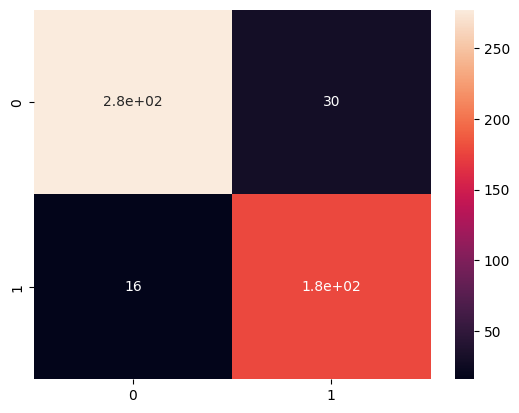

Training: ResNet50
Epoch: 1
Epoch: 2
Epoch: 3
Epoch: 4
Epoch: 5
Accuracy: 0.9401197604790419
              precision    recall  f1-score   support

           0       0.95      0.95      0.95       307
           1       0.93      0.92      0.92       194

    accuracy                           0.94       501
   macro avg       0.94      0.94      0.94       501
weighted avg       0.94      0.94      0.94       501



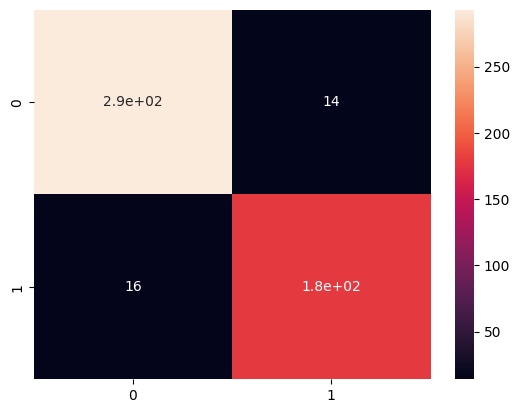

Training: DenseNet
Epoch: 1
Epoch: 2
Epoch: 3
Epoch: 4
Epoch: 5
Accuracy: 0.9580838323353293
              precision    recall  f1-score   support

           0       0.98      0.95      0.97       307
           1       0.92      0.97      0.95       194

    accuracy                           0.96       501
   macro avg       0.95      0.96      0.96       501
weighted avg       0.96      0.96      0.96       501



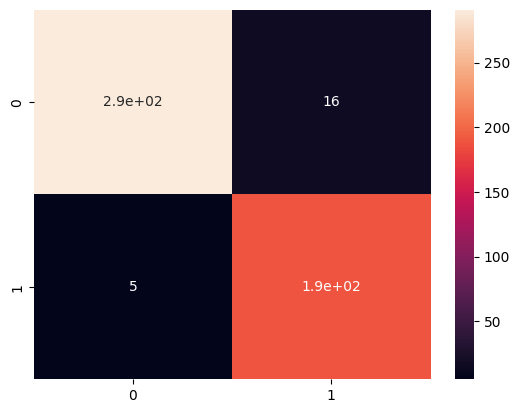

Training: Hybrid


RuntimeError: input.size(-1) must be equal to input_size. Expected 512, got 25088

In [ ]:
models_dict = {

    "CNN":CNN(),

    "ResNet50":get_resnet(),

    "DenseNet":get_densenet(),

    "Hybrid":HybridModel()
}

results={}

for name,model in models_dict.items():

    print("Training:",name)

    trained=train_model(model)

    acc=evaluate_model(trained)

    results[name]=acc

A

In [ ]:
Accuracy Comparison

SyntaxError: invalid syntax (1537183824.py, line 1)

      Model  Accuracy
0       CNN  0.908184
1  ResNet50  0.940120
2  DenseNet  0.958084


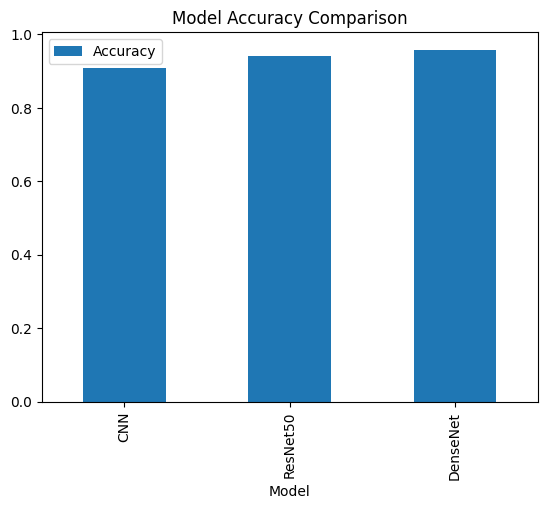

In [ ]:
import pandas as pd

df=pd.DataFrame(list(results.items()),columns=["Model","Accuracy"])

print(df)

df.plot(x="Model",y="Accuracy",kind="bar")

plt.title("Model Accuracy Comparison")

plt.show()

Grad-Cam Visualization

In [ ]:
def gradcam(model,img_tensor):

    gradients=[]
    activations=[]

    def backward_hook(module,grad_in,grad_out):
        gradients.append(grad_out[0])

    def forward_hook(module,input,output):
        activations.append(output)

    for m in model.modules():
        if isinstance(m,nn.Conv2d):
            last_conv=m

    last_conv.register_forward_hook(forward_hook)
    last_conv.register_backward_hook(backward_hook)

    output=model(img_tensor)

    pred=output.argmax()

    loss=output[:,pred]

    model.zero_grad()

    loss.backward()

    grads=gradients[0].cpu().data.numpy()[0]

    acts=activations[0].cpu().data.numpy()[0]

    weights=np.mean(grads,axis=(1,2))

    cam=np.zeros(acts.shape[1:],dtype=np.float32)

    for i,w in enumerate(weights):
        cam+=w*acts[i]

    cam=np.maximum(cam,0)

    cam=cv2.resize(cam,(224,224))

    cam=(cam-np.min(cam))/(np.max(cam)-np.min(cam))

    return cam

Efficient Net

In [ ]:
from torchvision.models import efficientnet_b0

def get_efficientnet():

    model = efficientnet_b0(pretrained=True)

    model.classifier[1] = nn.Linear(model.classifier[1].in_features,2)

    return model

Attention Layer

In [ ]:
class AttentionBlock(nn.Module):

    def __init__(self,in_channels):

        super().__init__()

        self.pool = nn.AdaptiveAvgPool2d(1)

        self.fc = nn.Sequential(

            nn.Linear(in_channels,in_channels//4),

            nn.ReLU(),

            nn.Linear(in_channels//4,in_channels),

            nn.Sigmoid()

        )

    def forward(self,x):

        b,c,h,w = x.size()

        y = self.pool(x).view(b,c)

        y = self.fc(y).view(b,c,1,1)

        return x * y

CNN+Attention Layer

In [ ]:
class CNN_Attention(nn.Module):

    def __init__(self):

        super().__init__()

        self.conv1 = nn.Conv2d(3,32,3,padding=1)

        self.att1 = AttentionBlock(32)

        self.pool = nn.MaxPool2d(2)

        self.conv2 = nn.Conv2d(32,64,3,padding=1)

        self.att2 = AttentionBlock(64)

        self.fc = nn.Sequential(

            nn.Linear(64*56*56,128),

            nn.ReLU(),

            nn.Linear(128,2)

        )

    def forward(self,x):

        x = self.pool(self.att1(torch.relu(self.conv1(x))))

        x = self.pool(self.att2(torch.relu(self.conv2(x))))

        x = x.view(x.size(0),-1)

        return self.fc(x)

Ensemble model

In [ ]:
class EnsembleModel(nn.Module):

    def __init__(self):

        super().__init__()

        self.resnet = models.resnet18(pretrained=True)

        self.resnet.fc = nn.Identity()

        self.densenet = models.densenet121(pretrained=True)

        self.densenet.classifier = nn.Identity()

        self.efficient = efficientnet_b0(pretrained=True)

        self.efficient.classifier = nn.Identity()

        self.fc = nn.Linear(512+1024+1280,2)

    def forward(self,x):

        f1 = self.resnet(x)

        f2 = self.densenet(x)

        f3 = self.efficient(x)

        features = torch.cat((f1,f2,f3),dim=1)

        return self.fc(features)

Train Advanced Model

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 230MB/s]
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Training: EfficientNet
Epoch: 1
Epoch: 2
Epoch: 3
Epoch: 4
Epoch: 5
Accuracy: 0.9820359281437125
              precision    recall  f1-score   support

           0       1.00      0.97      0.99       307
           1       0.96      0.99      0.98       194

    accuracy                           0.98       501
   macro avg       0.98      0.98      0.98       501
weighted avg       0.98      0.98      0.98       501



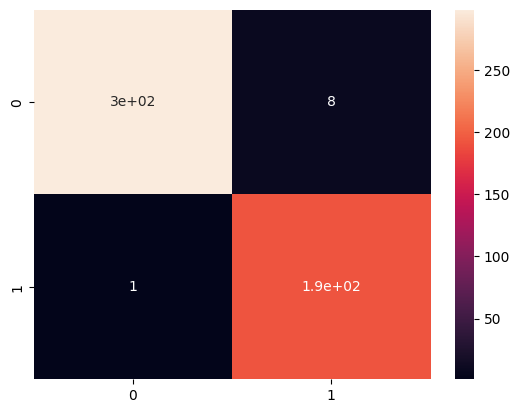

Training: CNN_Attention
Epoch: 1
Epoch: 2
Epoch: 3
Epoch: 4
Epoch: 5
Accuracy: 0.8862275449101796
              precision    recall  f1-score   support

           0       0.91      0.91      0.91       307
           1       0.85      0.85      0.85       194

    accuracy                           0.89       501
   macro avg       0.88      0.88      0.88       501
weighted avg       0.89      0.89      0.89       501



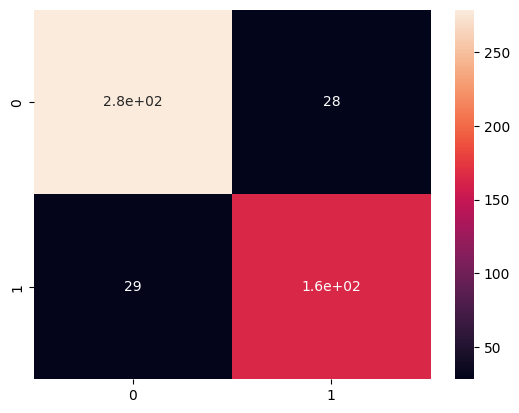

Training: Ensemble
Epoch: 1
Epoch: 2
Epoch: 3
Epoch: 4
Epoch: 5
Accuracy: 0.9920159680638723
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       307
           1       0.99      0.99      0.99       194

    accuracy                           0.99       501
   macro avg       0.99      0.99      0.99       501
weighted avg       0.99      0.99      0.99       501



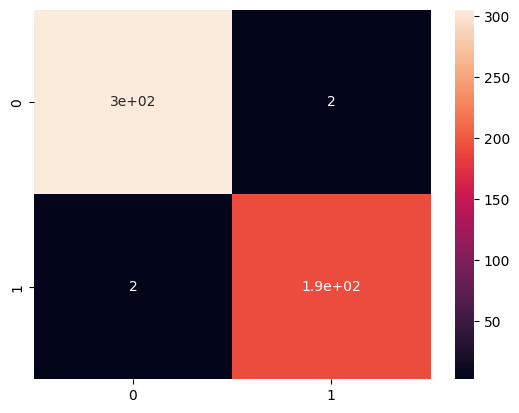

In [ ]:
advanced_models = {

    "EfficientNet":get_efficientnet(),

    "CNN_Attention":CNN_Attention(),

    "Ensemble":EnsembleModel()

}

for name,model in advanced_models.items():

    print("Training:",name)

    trained = train_model(model)

    acc = evaluate_model(trained)

    results[name] = acc

           Model  Accuracy
0            CNN  0.908184
1       ResNet50  0.940120
2       DenseNet  0.958084
3   EfficientNet  0.982036
4  CNN_Attention  0.886228
5       Ensemble  0.992016


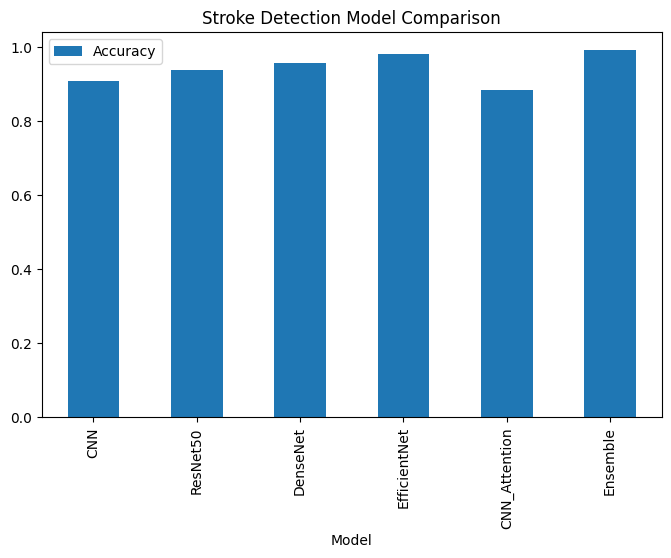

In [ ]:
import pandas as pd

df = pd.DataFrame(list(results.items()),columns=["Model","Accuracy"])

print(df)

df.plot(x="Model",y="Accuracy",kind="bar",figsize=(8,5))

plt.title("Stroke Detection Model Comparison")

plt.show()

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1867: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


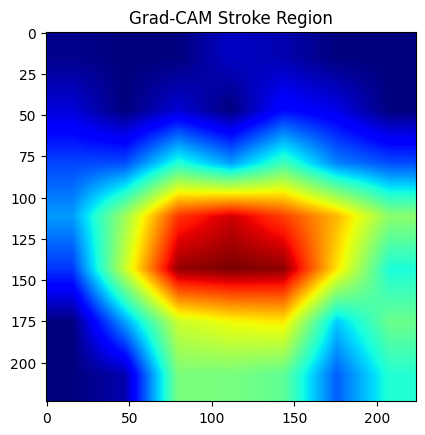

In [ ]:
image,label = test_dataset[0]

img_tensor = image.unsqueeze(0).to(device)

cam = gradcam(trained,img_tensor)

plt.imshow(cam,cmap='jet')

plt.title("Grad-CAM Stroke Region")

plt.show()

In [ ]:
torch.save(model.state_dict(),
           "resnet50_stroke.pth")

In [ ]:
from google.colab import files
files.download("resnet50_stroke.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import torch
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485,0.456,0.406],
        [0.229,0.224,0.225]
    )
])

def preprocess(image):
    img = transform(image)
    img = img.unsqueeze(0)
    return img

In [ ]:
import torch
import numpy as np

def generate_gradcam(model,input_tensor):

    for name,module in model.named_modules():
        if "layer4" in name:
            target_layer = module

    gradients = []
    activations = []

    def backward_hook(module,grad_in,grad_out):
        gradients.append(grad_out[0])

    def forward_hook(module,input,output):
        activations.append(output)

    target_layer.register_forward_hook(forward_hook)
    target_layer.register_backward_hook(backward_hook)

    output = model(input_tensor)

    class_idx = torch.argmax(output)

    loss = output[0,class_idx]

    model.zero_grad()
    loss.backward()

    grad = gradients[0].cpu().data.numpy()[0]
    act = activations[0].cpu().data.numpy()[0]

    weights = np.mean(grad,axis=(1,2))

    cam = np.zeros(act.shape[1:],dtype=np.float32)

    for i,w in enumerate(weights):
        cam += w*act[i]

    cam = np.maximum(cam,0)
    cam = cam / cam.max()

    return cam